In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Dataset\FIFA PLAYER SKOR.csv')
df.head(5)

<>:1: SyntaxWarning: invalid escape sequence '\F'
<>:1: SyntaxWarning: invalid escape sequence '\F'
C:\Users\HP\AppData\Local\Temp\ipykernel_23512\1404250217.py:1: SyntaxWarning: invalid escape sequence '\F'
  df = pd.read_csv('Dataset\FIFA PLAYER SKOR.csv')


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [4]:
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

In [5]:
df.isna().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [7]:
df.head(5)

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


### 1. Analisis Pemain & PosisiRata-rata Rating vs Harga: 
1. Posisi mana yang memiliki rata-rata Overall_Rating tertinggi, dan apakah posisi tersebut juga memiliki rata-rata Value Per M$ tertinggi?
2. Siapakah pemain "undervalued" (pemain dengan Overall_Rating tinggi namun memiliki Value Per M$ di atas rata-rata)?
3. Berapa selisih antara Overall_Rating saat ini dengan Future Potential berdasarkan posisi pemain?

### 2. Analisis Umur & PotensiUsia Emas: 
1. Pada rentang usia (Age) berapakah pemain biasanya mencapai puncak Overall_Rating mereka?
2. Apakah ada korelasi yang kuat antara Future Potential seorang pemain muda dengan Value Per M$ mereka saat ini?
3. Siapakah 5 pemain muda (di bawah 21 tahun) yang memiliki selisih terbesar antara Overall_Rating dan Future Potential?

### 3. Analisis Negara & TimDominasi Negara:
1. Negara (Country) mana yang menyumbangkan pemain paling banyak dengan Overall_Rating di atas 85?
2. Tim (Team) manakah yang memiliki skuad paling efisien (rata-rata Total_Stats Score tinggi namun total Value Per M$ rendah)?
3. Distribusi Statistik: Bagaimana distribusi Total_Stats Score pemain jika dibandingkan antar negara?

### 4. Analisis Nilai EkonomiPenentu Harga:
1. apakah Overall_Rating ataukah Future Potential?
2. Apakah pemain dengan Total_Stats Score yang tinggi selalu memiliki harga jual (Value Per M$) yang tinggi pula?
3. Jika kita mengelompokkan pemain berdasarkan Age, bagaimana tren penurunan Value Per M$ seiring bertambahnya usia pemain?

### 5. Analisis StatistikOutlier Performa: 
1. Siapakah pemain yang memiliki Total_Stats Score tertinggi namun tidak bermain di Team besar?
2. Bagaimana perbandingan rata-rata Total_Stats Score untuk pemain dengan posisi Goalkeeper dibandingkan dengan posisi Midfielder?

In [8]:
df.head(5)

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


### 1. Analisis Pemain & PosisiRata-rata Rating vs Harga: 
1. Posisi mana yang memiliki rata-rata Overall_Rating tertinggi, dan apakah posisi tersebut juga memiliki rata-rata Value Per M$ tertinggi?
2. Siapakah pemain "undervalued" (pemain dengan Overall_Rating tinggi namun memiliki Value Per M$ di bawah rata-rata)?
3. Berapa selisih antara Overall_Rating saat ini dengan Future Potential berdasarkan posisi pemain?

In [103]:
# soal nomor 1
meanRating = df['Overall_Rating'].mean().round(2)
meanValue = df['Value Per M$'].mean().round(2)

Value = df.loc[((df['Overall_Rating'] > meanRating) & (df['Value Per M$']>meanValue)),['Position','Value Per M$','Overall_Rating']]
positionValue = Value.sort_values(by=['Value Per M$','Overall_Rating'], ascending=False)

hasil = positionValue['Position'].iloc[0] if not positionValue.empty else "Pemain tidak ditemukan"
print(f"Posisi tersebut adalah: {hasil}")

positionValue

Posisi tersebut adalah: LW


,Position,Value Per M$,Overall_Rating
103,LW,190.5,91
67,ST,176.5,90
110,LW,109.0,86
370,CAM,107.5,91
214,CB,107.5,88
...,...,...,...
810,LW,2.6,67
824,RM,2.6,67
933,CAM,2.6,67
1123,CDM,2.6,67


C:\Users\HP\AppData\Local\Temp\ipykernel_23512\3720198918.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Position', y='Value Per M$', palette=colors)


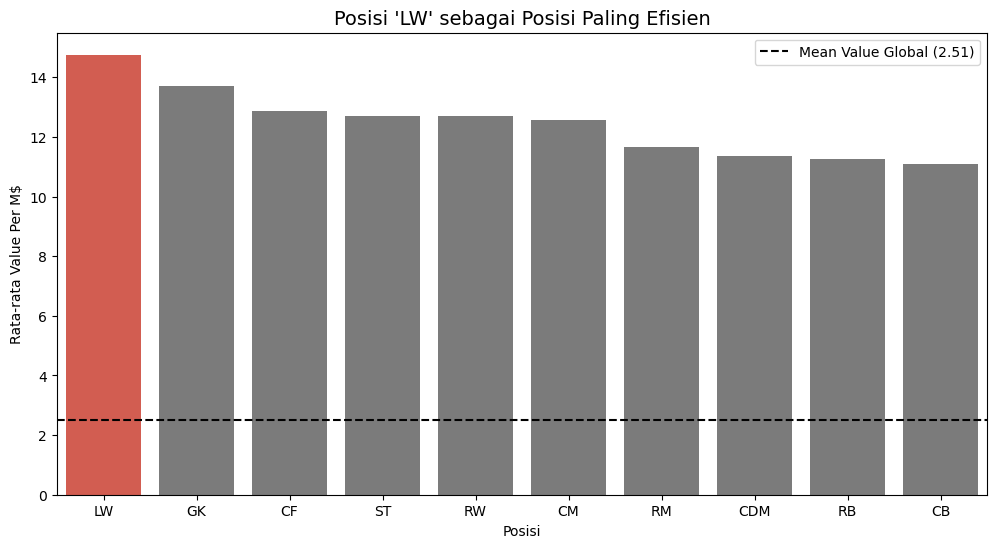

In [129]:
if not Value.empty:

    df_plot = Value.groupby('Position').mean().reset_index()
    df_plot = df_plot.sort_values('Value Per M$', ascending=False).head(10)
    
    # Target: Posisi pertama hasil filter Anda (hasil)
    target_pos = hasil 
    
    plt.figure(figsize=(12, 6))
    
    # 2. Logika Warna: Merah untuk posisi target, biru untuk posisi lainnya
    colors = ['#e74c3c' if (x == target_pos) else "#7b7b7b" for x in df_plot['Position']]
    
    # 3. Plot menggunakan 'Value Per M$' sebagai sumbu Y
    sns.barplot(data=df_plot, x='Position', y='Value Per M$', palette=colors)
    
    # 4. Tambahkan garis horizontal rata-rata global sebagai referensi
    plt.axhline(meanValue, color='black', linestyle='--', label=f'Mean Value Global ({meanValue})')
    
    plt.title(f"Posisi '{target_pos}' sebagai Posisi Paling Efisien", fontsize=14)
    plt.xlabel('Posisi')
    plt.ylabel('Rata-rata Value Per M$')
    plt.legend()
    plt.show()
else:
    print("Data tidak ditemukan untuk divisualisasikan.")


In [70]:
# soal nomor 2
topRating= df['Overall_Rating'].max()
meanValue = df['Value Per M$'].mean()
pemain = df.loc[((df['Overall_Rating'] == topRating) & (df['Value Per M$'] > meanValue)), ['Name','Team','Overall_Rating','Value Per M$']]
pemain_termahal = pemain.sort_values(by='Value Per M$', ascending=False)

hasil = pemain_termahal['Name'].iloc[0] if not pemain_termahal.empty else "Pemain yang dimaksud tidak ada"
print(f"Pemain tersebut adalah: {hasil}")



Pemain tersebut adalah: Kylian Mbappé


C:\Users\HP\AppData\Local\Temp\ipykernel_23512\298879246.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_team, x='Name', y='Overall_Rating', palette=colors)


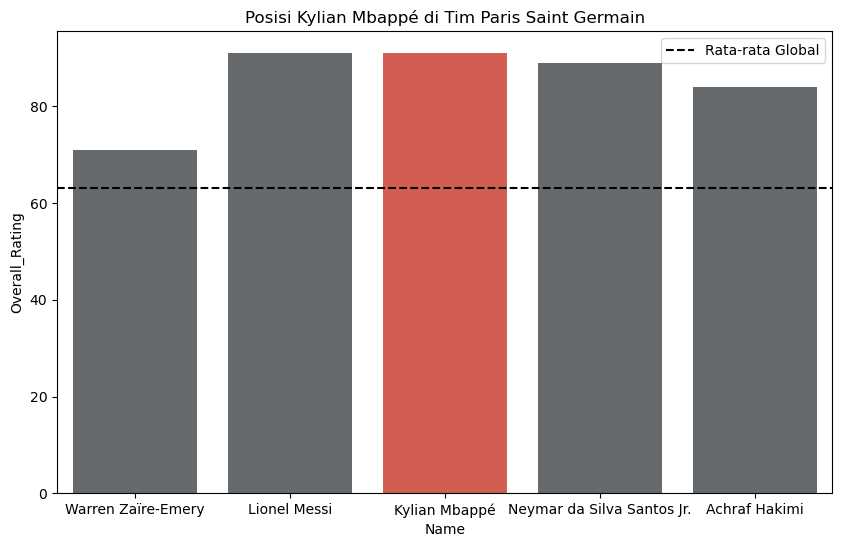

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score,Gap_potential
36,Warren Zaïre-Emery,France,CDM,16,71,88,Paris Saint Germain,4.7,1903,-17
98,Lionel Messi,Argentina,RW,35,91,91,Paris Saint Germain,54.0,2190,0
103,Kylian Mbappé,France,LW,23,91,95,Paris Saint Germain,190.5,2181,-4
130,Neymar da Silva Santos Jr.,Brazil,LW,30,89,89,Paris Saint Germain,99.5,2157,0
177,Achraf Hakimi,Morocco,RWB,23,84,87,Paris Saint Germain,53.5,2229,-3


In [106]:

# Pastikan kita tahu siapa tim pemain tersebut
if not pemain_termahal.empty:
    target_player = pemain_termahal.iloc[0]['Name']
    target_team = pemain_termahal.iloc[0]['Team']
    
    # Ambil data pemain di tim yang sama untuk perbandingan
    df_team = df[df['Team'] == target_team].head(5)
    
    plt.figure(figsize=(10, 6))
    
    # Warna: Merah untuk pemain target, biru untuk rekan setimnya
    colors = ['#e74c3c' if (x == target_player) else "#656a6d" for x in df_team['Name']]
    
    sns.barplot(data=df_team, x='Name', y='Overall_Rating', palette=colors)
    
    # Tambahkan garis horizontal untuk Mean Value sebagai referensi visual
    plt.axhline(df['Overall_Rating'].mean(), color='black', linestyle='--', label='Rata-rata Global')
    
    plt.title(f"Posisi {target_player} di Tim {target_team}")
    plt.legend()
    plt.show()
else:
    print("Pemain tidak ditemukan, tidak ada data untuk divisualisasikan.")


df_team

In [130]:
#soal nomor 3
df['Gap_potential']= df['Overall_Rating'] - df['Future Potential']
gapPerposition = df.groupby('Position')[['Gap_potential']].mean().sort_values(by='Gap_potential',ascending=False)
gapPerposition.head(5)

,Gap_potential
Position,
SW,-4.000000
RF,-4.000000
RWB,-6.269360
CDM,-6.613402
LWB,-6.930000


C:\Users\HP\AppData\Local\Temp\ipykernel_23512\2269088891.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


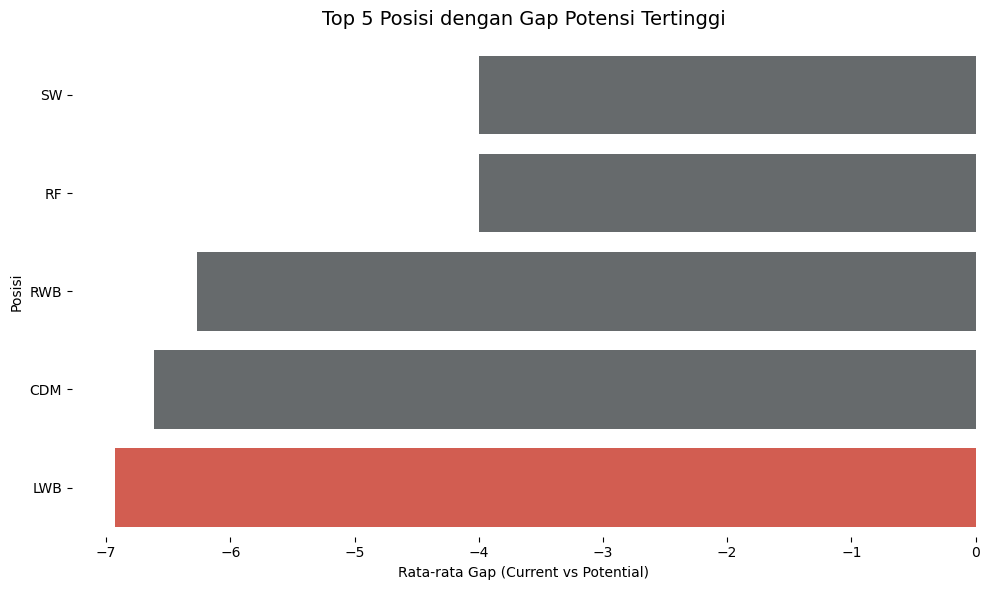

In [138]:
df_plot = gapPerposition.head(5).reset_index()

plt.figure(figsize=(10, 6))

max_gap = df_plot['Gap_potential'].min()

colors = ['#e74c3c' if (x == max_gap) else "#656a6d" for x in df_plot['Gap_potential']]

# Menggunakan Bar Chart Horizontal (y='Position') agar label posisi mudah dibaca
sns.barplot(
    data=df_plot, 
    x='Gap_potential', 
    y='Position', 
    palette= colors 
)

plt.title('Top 5 Posisi dengan Gap Potensi Tertinggi', fontsize=14, pad=15)
plt.xlabel('Rata-rata Gap (Current vs Potential)')
plt.ylabel('Posisi')

# Menghilangkan garis tepi agar lebih bersih
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()